# 07 — Word2Vec Embeddings & t-SNE
**Inputs:** `data/docs_sampled.csv`, `data/hc3_VOCAB.csv`

**Outputs:** `data/hc3_VOCAB_W2V.csv`

**Images:** `images/w2v_tsne.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from nltk.tokenize import word_tokenize
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [2]:
docs_sampled = pd.read_csv('../data/docs_sampled.csv')
VOCAB= pd.read_csv('../data/hc3_VOCAB.csv').set_index('term_str')
print(f'Loaded {len(docs_sampled):,} documents')

Loaded 10,258 documents


## Train Word2Vec

In [3]:
sentences= [word_tokenize(str(text).lower()) for text in docs_sampled['text']]

w2v_model =Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=10,
    seed=42
)
print(f'Vocabulary size: {len(w2v_model.wv):,}')
print('\nWords most similar to "human":')
print(w2v_model.wv.most_similar('human', topn=5))
print('\nWords most similar to "chatgpt":')
try:
    print(w2v_model.wv.most_similar('chatgpt', topn=5))
except:
    print('(chatgpt not in vocabulary — too rare)')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size: 12,807

Words most similar to "human":
[('humans', 0.6118713617324829), ('biological', 0.569830060005188), ('natural', 0.556013822555542), ('our', 0.5522226095199585), ('evolution', 0.5511285066604614)]

Words most similar to "chatgpt":
[('dec', 0.9763937592506409), ('···', 0.9059844613075256), ('\u200b', 0.8902742862701416), ('dr.', 0.7765078544616699), ('22', 0.7566199898719788)]


## VOCAB_W2V Table

In [4]:
w2v_terms= [t for t in VOCAB.index if t in w2v_model.wv]
w2v_vectors = np.array([w2v_model.wv[t] for t in w2v_terms])
feat_cols= [f'w2v_{i}' for i in range(100)]
VOCAB_W2V = pd.DataFrame(w2v_vectors, index=w2v_terms, columns=feat_cols)
VOCAB_W2V.index.name ='term_str'
VOCAB_W2V.to_csv('../data/hc3_VOCAB_W2V.csv')
print(f'VOCAB_W2V shape: {VOCAB_W2V.shape}')
VOCAB_W2V.head()

VOCAB_W2V shape: (12792, 100)


,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,...,w2v_90,w2v_91,w2v_92,w2v_93,w2v_94,w2v_95,w2v_96,w2v_97,w2v_98,w2v_99
term_str,,,,,,,,,,,,,,,,,,,,,
.,0.833048,-0.508602,0.318065,-1.184966,-0.429401,-0.204620,-1.083599,0.267833,-0.371176,0.757488,...,-1.507685,-1.491263,-1.449427,-1.229580,1.951922,0.895851,-0.770964,-0.447334,-0.686607,1.134318
it,-2.333594,0.496267,-0.249943,-0.278805,0.176654,1.928304,-0.755196,-0.308743,-0.757669,0.378578,...,-1.964122,-0.218703,-1.172557,0.445334,-1.576295,0.613244,0.181455,-0.512686,-2.215972,0.535014
is,-1.260679,0.639035,-1.036351,-1.350417,0.407813,-0.036013,-1.059738,-1.608607,-0.846432,0.608287,...,-2.071293,-0.501762,2.990273,0.679758,-0.014414,-0.456738,0.923267,1.929409,1.060965,-2.960595
of,1.880857,1.413730,-0.143882,-0.480273,-0.587789,1.537685,-0.154931,0.977403,1.465364,2.240641,...,2.070889,0.255476,0.749509,-0.291487,-0.740778,1.344075,-1.648108,-0.674677,-1.845575,-2.485629
and,-0.184760,-0.195734,0.828866,0.085072,-1.172755,1.166128,-1.230046,0.020260,-1.403446,-0.085496,...,0.265044,0.049409,-3.388443,0.326789,-1.051057,0.507394,0.527010,-1.002792,-0.695900,1.462550


## t-SNE Visualization

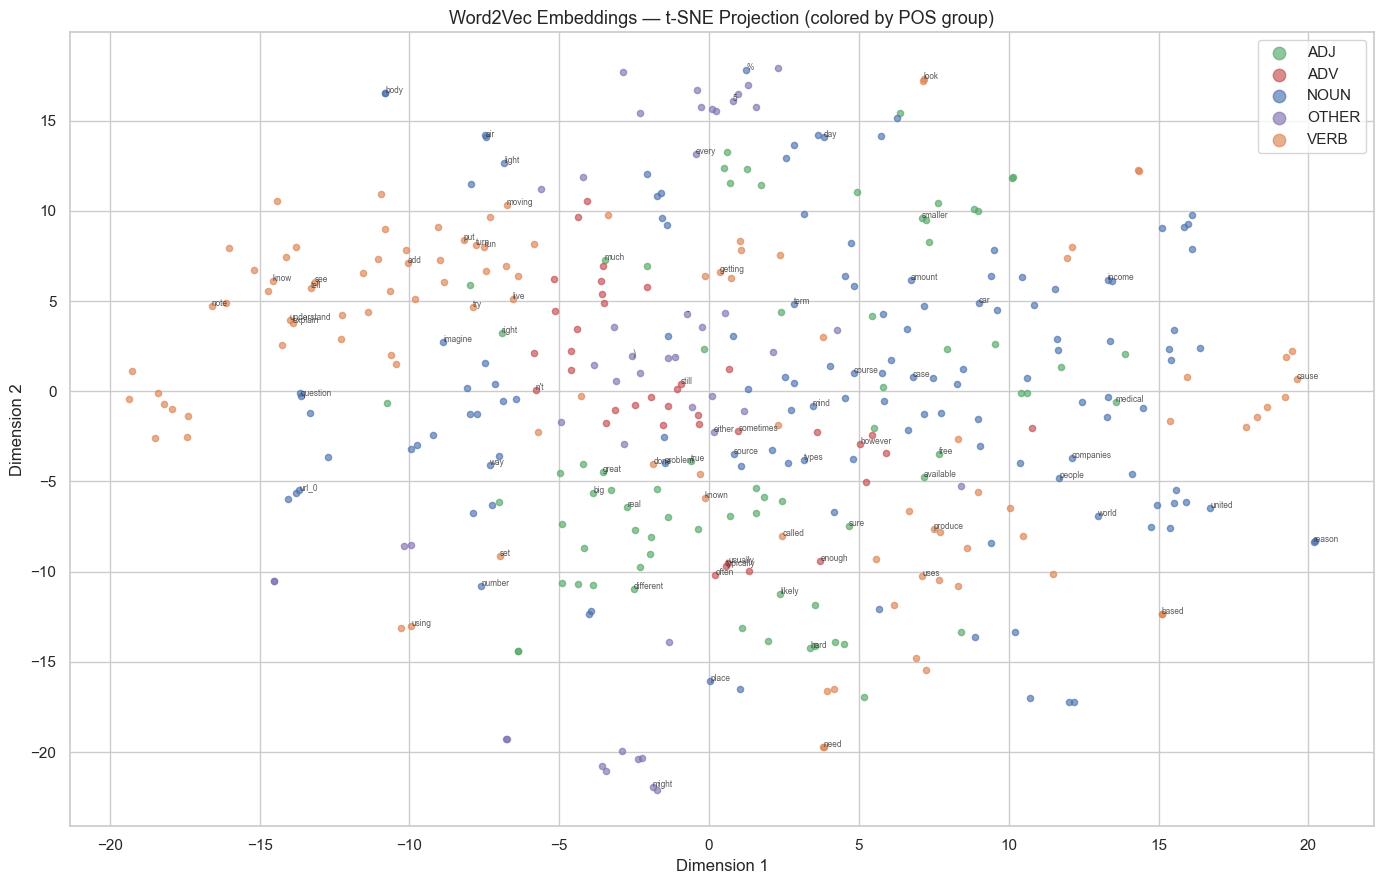

Saved images/w2v_tsne.png


In [5]:
top500 = [t for t in VOCAB.index[:500] if t in w2v_model.wv and not VOCAB.loc[t,'stop']]
vecs500 = np.array([w2v_model.wv[t] for t in top500])

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_result =tsne.fit_transform(vecs500)

tsne_df =pd.DataFrame(tsne_result, index=top500, columns=['x','y'])
tsne_df['pos_group'] = tsne_df.index.map(
    lambda t: VOCAB.loc[t,'max_pos_group'] if t in VOCAB.index else 'OTHER'
)

PG_COLORS = {'NOUN':'#4C72B0','VERB':'#DD8452','ADJ':'#55A868','ADV':'#C44E52','OTHER':'#8172B2'}

fig, ax= plt.subplots(figsize=(14, 9))
for pg, grp in tsne_df.groupby('pos_group'):
    ax.scatter(grp['x'], grp['y'], c=PG_COLORS.get(pg,'gray'),
               label=pg, alpha=0.65, s=20)

for term, row in tsne_df.sample(80, random_state=42).iterrows():
    ax.annotate(term, (row['x'], row['y']), fontsize=6, alpha=0.75)

ax.set_title('Word2Vec Embeddings — t-SNE Projection (colored by POS group)', fontsize=13)
ax.legend(fontsize=11, markerscale=2)
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
plt.tight_layout()
plt.savefig('../images/w2v_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved images/w2v_tsne.png')